In [ ]:
import zipfile

with zipfile.ZipFile("PlantVillage.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/PlantVillage")

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [ ]:
train_path = "/content/PlantVillage/PlantVillage/train"
val_path = "/content/PlantVillage/PlantVillage/val"

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras.models import load_model

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.optimizers import Adam

In [ ]:
IMAGE_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.8, 1.2]
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 43444 images belonging to 38 classes.
Found 10861 images belonging to 38 classes.


In [ ]:
efficientnet_model = load_model(
    "efficientnet_plant_disease.h5"
)

print("Model loaded successfully.")

Model loaded successfully.


In [ ]:
efficientnet_model.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,387,275 (16.74 MB)

 Trainable params: 337,702 (1.29 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 2 (12.00 B)

In [ ]:
efficientnet_model.trainable = True

In [ ]:
for layer in efficientnet_model.layers[:-20]:
    layer.trainable = False

In [ ]:
efficientnet_model.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,387,275 (16.74 MB)

 Trainable params: 337,702 (1.29 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 2 (12.00 B)

In [ ]:
efficientnet_model.trainable = True
print(len(efficientnet_model.layers))

242


In [ ]:
for layer in efficientnet_model.layers[:-20]:
    layer.trainable = False

for layer in efficientnet_model.layers[-20:]:
    layer.trainable = True

In [ ]:
trainable_layers = 0

for layer in efficientnet_model.layers:
    if layer.trainable:
        trainable_layers += 1

print("Trainable layers:", trainable_layers)

Trainable layers: 20


In [ ]:
efficientnet_model.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,387,275 (16.74 MB)

 Trainable params: 1,467,094 (5.60 MB)

 Non-trainable params: 2,920,179 (11.14 MB)

 Optimizer params: 2 (12.00 B)

In [ ]:
from tensorflow.keras.optimizers import Adam

efficientnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "best_finetuned_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

In [ ]:
history_finetune = efficientnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=3,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/3
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.7986 - loss: 0.7211

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 714s 500ms/step - accuracy: 0.8429 - loss: 0.5307 - val_accuracy: 0.9470 - val_loss: 0.1583 - learning_rate: 1.0000e-05
Epoch 2/3
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.8912 - loss: 0.3298

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 631s 464ms/step - accuracy: 0.9000 - loss: 0.3094 - val_accuracy: 0.9565 - val_loss: 0.1266 - learning_rate: 1.0000e-05
Epoch 3/3
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.9092 - loss: 0.2749

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 632s 465ms/step - accuracy: 0.9139 - loss: 0.2626 - val_accuracy: 0.9621 - val_loss: 0.1119 - learning_rate: 1.0000e-05


In [ ]:
efficientnet_model.save("final_agrivision_model.keras")

print("Final model saved successfully.")

Final model saved successfully.


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import seaborn as sns

In [ ]:
val_generator.reset()

In [ ]:
pred_probs = efficientnet_model.predict(val_generator)

340/340 ━━━━━━━━━━━━━━━━━━━━ 30s 68ms/step


In [ ]:
pred_classes = np.argmax(pred_probs, axis=1)

true_classes = val_generator.classes

class_labels = list(val_generator.class_indices.keys())

In [ ]:
val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 10861 images belonging to 38 classes.


In [ ]:
val_generator.reset()

In [ ]:
pred_probs = efficientnet_model.predict(val_generator)

340/340 ━━━━━━━━━━━━━━━━━━━━ 18s 53ms/step


In [ ]:
pred_classes = np.argmax(pred_probs, axis=1)

true_classes = val_generator.classes

class_labels = list(val_generator.class_indices.keys())

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    true_classes,
    pred_classes,
    target_names=class_labels
)

print(report)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.84      0.91       126
                                 Apple___Black_rot       0.95      0.99      0.97       125
                          Apple___Cedar_apple_rust       0.98      0.91      0.94        55
                                   Apple___healthy       0.96      0.98      0.97       329
                               Blueberry___healthy       0.98      1.00      0.99       300
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       210
                 Cherry_(including_sour)___healthy       0.99      0.99      0.99       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.93      0.68      0.79       103
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       239
               Corn_(maize)___Northern_Leaf_Blight       0.85      0.96      0.

In [ ]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input

In [ ]:
efficientnet_model = load_model(
    "final_agrivision_model.keras"
)

print("Model Loaded Successfully")


Model Loaded Successfully


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 22 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
from google.colab import files

uploaded = files.upload()



Saving image.jpg to image.jpg


In [ ]:
img_path = "image.jpg"


In [ ]:
img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)

img_array = np.expand_dims(
    img_array,
    axis=0
)

img_array = preprocess_input(
    img_array
)

In [ ]:
predictions = efficientnet_model.predict(
    img_array
)

predicted_class = np.argmax(
    predictions[0]
)

confidence = np.max(
    predictions[0]
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step


In [ ]:
class_labels = list(
    train_generator.class_indices.keys()
)

print("\nPredicted Disease:")
print(class_labels[predicted_class])

print("\nConfidence:")
print(round(confidence * 100, 2), "%")



Predicted Disease:
Tomato___Septoria_leaf_spot

Confidence:
51.06 %


In [ ]:
last_conv_layer_name = None

for layer in reversed(efficientnet_model.layers):

    if len(layer.output.shape) == 4:

        last_conv_layer_name = layer.name

        break

print("\nLast Conv Layer:")
print(last_conv_layer_name)



Last Conv Layer:
top_activation


In [ ]:
grad_model = tf.keras.models.Model(
    [efficientnet_model.inputs],
    [
        efficientnet_model.get_layer(
            last_conv_layer_name
        ).output,

        efficientnet_model.output
    ]
)


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


<Figure size 600x600 with 0 Axes>

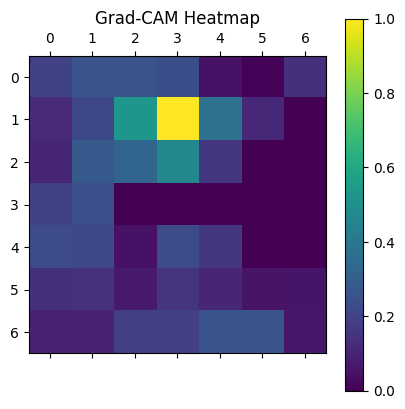

In [ ]:
with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(
        img_array
    )

    loss = predictions[:, predicted_class]

grads = tape.gradient(
    loss,
    conv_outputs
)

pooled_grads = tf.reduce_mean(
    grads,
    axis=(0,1,2)
)

conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

heatmap = tf.squeeze(heatmap)

heatmap = np.maximum(
    heatmap,
    0
)

heatmap /= np.max(heatmap)


# =========================
# STEP 11 — DISPLAY HEATMAP
# =========================

plt.figure(figsize=(6,6))

plt.matshow(heatmap)

plt.title("Grad-CAM Heatmap")

plt.colorbar()

plt.show()

In [ ]:
img_cv = cv2.imread(img_path)

img_cv = cv2.resize(
    img_cv,
    (224,224)
)

In [ ]:

heatmap = cv2.resize(
    heatmap,
    (224,224)
)

heatmap = np.uint8(
    255 * heatmap
)



In [ ]:

heatmap = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)



In [ ]:
superimposed_img = cv2.addWeighted(
    img_cv,
    0.5,
    heatmap,
    0.7,
    0
)

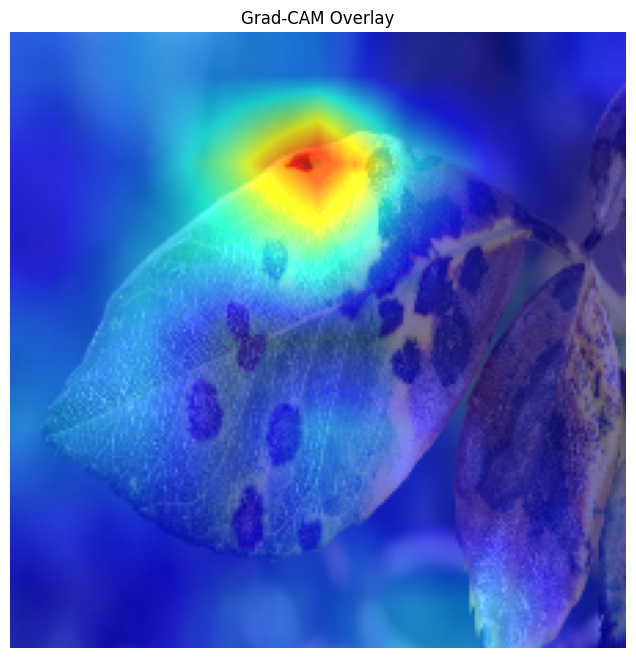

In [ ]:
plt.figure(figsize=(8,8))

plt.imshow(
    cv2.cvtColor(
        superimposed_img,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")

plt.title("Grad-CAM Overlay")

plt.show()